# **Roteiro Redes Neurais e Deep Learning**
## Utilizar este Notebook para executar os comandos.
**Arquivo de referência:** *Roteiro Redes Neurais e Deep Learning.docx*

In [1]:
import torch
import keras
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, MaxPool2D, Conv2D, GlobalMaxPool2D, Flatten, Dropout
from keras import ops, layers

from tensorflow.keras.datasets import mnist

In [2]:
model = Sequential(
    [
      Input(shape=(4,)),
      Dense(4, activation='relu', name='intermediary'),
      Dense(2)
    ]
)

In [3]:
model1 = Sequential()
model1.add(Dense(4, activation='relu'))
model1.add(Dense(2))

In [4]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ intermediary (Dense)            │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30 (120.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
print(model1.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
x = ops.ones((1,4))
print(x)

tf.Tensor([[1. 1. 1. 1.]], shape=(1, 4), dtype=float32)


In [7]:
model.weights

[<Variable path=sequential/intermediary/kernel, shape=(4, 4), dtype=float32, value=[[-0.3986672   0.38199526 -0.05756545 -0.70851624]
  [-0.03285021 -0.29881203  0.2857043  -0.8106523 ]
  [ 0.77653223 -0.74407375 -0.10186332  0.7994749 ]
  [-0.84155524  0.10415542 -0.73137236  0.3002506 ]]>,
 <Variable path=sequential/intermediary/bias, shape=(4,), dtype=float32, value=[0. 0. 0. 0.]>,
 <Variable path=sequential/dense/kernel, shape=(4, 2), dtype=float32, value=[[ 0.8060329   0.6386323 ]
  [ 0.46963882 -0.73305035]
  [ 0.6379099   0.438277  ]
  [-0.52617884  0.5192573 ]]>,
 <Variable path=sequential/dense/bias, shape=(2,), dtype=float32, value=[0. 0.]>]

In [8]:
y = model(x)
print(y)

tf.Tensor([[0. 0.]], shape=(1, 2), dtype=float32)


In [9]:
import torch
import tensorflow as tf
import os
import numpy as np
import keras
from keras import layers, ops

In [10]:
inputs = keras.Input(shape=(784,), name='digits')
x = layers.Dense(64, activation='relu', name='dense_1')(inputs)
x = layers.Dense(64, activation='relu', name='desnse_2')(x)
output = layers.Dense(10, activation='softmax', name='predictions')(x)

model = keras.Model(inputs=inputs, outputs=output)

In [11]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ digits (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ desnse_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
x_train.shape

(60000, 28, 28)

In [14]:
x_train = x_train.reshape(60000, 784).astype('float32')/255
x_test = x_test.reshape(10000, 784).astype('float32') / 255
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

x_val = x_train[-10000:]
y_val = y_train[-10000:]
x_train = x_train[:-10000]
y_train = y_train[:-10000]

In [15]:
x_train.shape

(50000, 784)

In [16]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()]
)

In [17]:
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=4,
    validation_data=(x_val, y_val)
)

Epoch 1/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5853 - sparse_categorical_accuracy: 0.8366 - val_loss: 0.2179 - val_sparse_categorical_accuracy: 0.9341
Epoch 2/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1714 - sparse_categorical_accuracy: 0.9493 - val_loss: 0.1493 - val_sparse_categorical_accuracy: 0.9558
Epoch 3/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1215 - sparse_categorical_accuracy: 0.9644 - val_loss: 0.1161 - val_sparse_categorical_accuracy: 0.9668
Epoch 4/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0955 - sparse_categorical_accuracy: 0.9709 - val_loss: 0.0980 - val_sparse_categorical_accuracy: 0.9720


In [18]:
print(history.history)

{'loss': [0.3489271104335785, 0.16395217180252075, 0.11868961900472641, 0.09298950433731079], 'sparse_categorical_accuracy': [0.9003999829292297, 0.9508399963378906, 0.9646000266075134, 0.9717599749565125], 'val_loss': [0.21787886321544647, 0.14930783212184906, 0.11610893905162811, 0.09800319373607635], 'val_sparse_categorical_accuracy': [0.9340999722480774, 0.9557999968528748, 0.9667999744415283, 0.972000002861023]}


In [19]:
results = model.evaluate(x_test, y_test, batch_size=128)
print(results)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1119 - sparse_categorical_accuracy: 0.9636
[0.09882115572690964, 0.9686999917030334]


In [20]:
print(y_test[0])
print(y_test[1])
print(y_test[2])

7.0
2.0
1.0


In [21]:
predictions = model.predict(x_test[:3])
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[[1.9214048e-07 4.8019910e-10 1.0973517e-05 2.2071990e-04 2.1830539e-11
  5.7216346e-07 4.6175754e-12 9.9976653e-01 2.5675154e-08 9.7726002e-07]
 [5.1403458e-07 3.6717236e-05 9.9982530e-01 1.8695046e-05 8.3789600e-11
  3.7006095e-07 4.1065385e-07 1.3996573e-09 1.1807162e-04 7.4054225e-09]
 [6.4037085e-06 9.9687505e-01 5.4105860e-04 4.5447327e-05 1.6148410e-04
  9.8388729e-05 1.4108584e-04 1.4208333e-03 6.5552181e-04 5.4686108e-05]]


In [22]:
print('test_loss, test acc:', results,'| predictions shape: ', predictions.shape)

test_loss, test acc: [0.09882115572690964, 0.9686999917030334] | predictions shape:  (3, 10)


In [23]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dropout, Dense

In [24]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], x_train.shape[2], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], x_test.shape[2], 1))

In [25]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [26]:
x_train = x_train/255
x_test = x_test/255

In [28]:
model = Sequential()
model.add(Conv2D(32, 3, activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D(2,2,))

model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [31]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

In [58]:
processo = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9982 - val_loss: 0.0048
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9981 - loss: 0.0062 - val_accuracy: 0.9992 - val_loss: 0.0030
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9997 - loss: 0.0010 - val_accuracy: 0.9972 - val_loss: 0.0093
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9984 - loss: 0.0049 - val_accuracy: 0.9965 - val_loss: 0.0084
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 0.9987 - val_loss: 0.0033
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9990 - loss: 0.0027 - val_accuracy: 0.9968 - val_loss: 0.0124
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.9988 - loss: 0.0036 - val_accuracy: 0.9973 - val_loss: 0.0081
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - accuracy: 0.9999 -

In [38]:
import matplotlib.pyplot as plt

model.evaluate(x_test, y_test)
model.predict(x_test[:1])



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9840 - loss: 0.0745
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[4.2958883e-12, 4.4543995e-12, 2.1852345e-11, 6.5709699e-12,
        1.0256464e-13, 2.7842929e-16, 2.2316098e-22, 1.0000000e+00,
        6.1644449e-15, 8.4736878e-13]], dtype=float32)

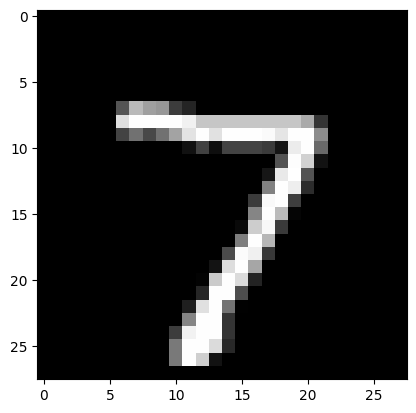

In [57]:
plt.imshow(x_test[0], cmap='gray')


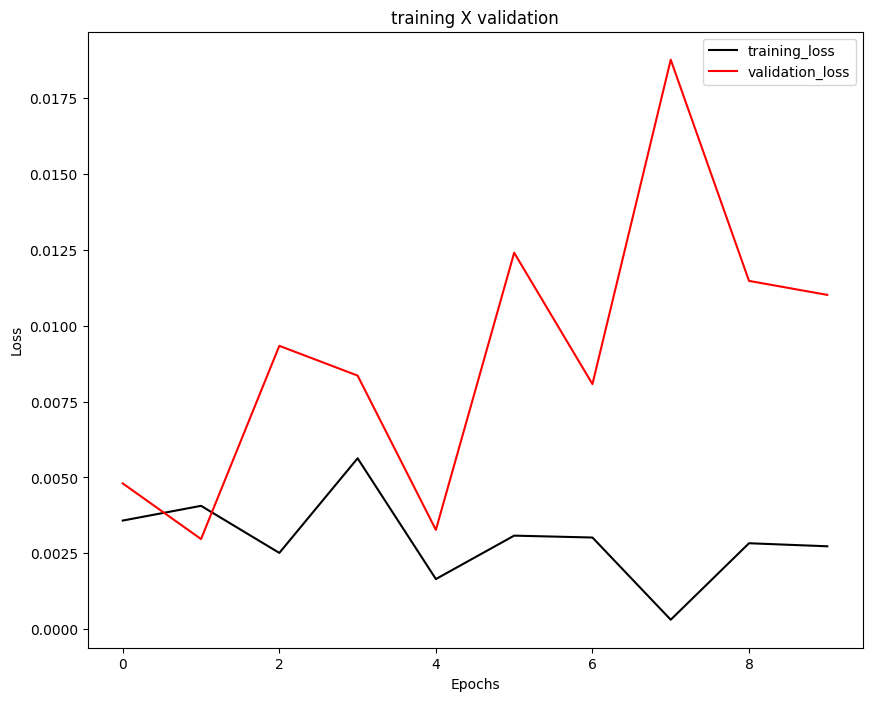

In [59]:
fig = plt.figure(figsize=(10,8))
ax = fig.gca()

ax.set(title='training X validation')
ax.plot(processo.history['loss'], color='black', label='training_loss')
ax.plot(processo.history['val_loss'], color='red', label='validation_loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.show()


In [60]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Dropout, Flatten
from tensorflow.keras.datasets import cifar10

In [61]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [62]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


Text(0.5, 1.0, 'Label: [4]')

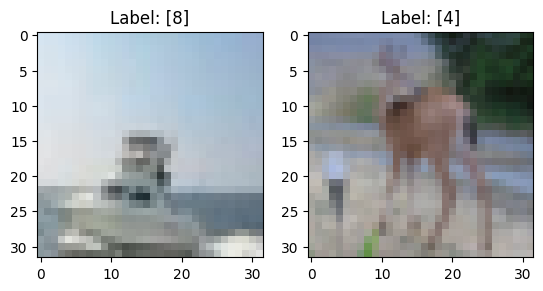

In [63]:
np.unique(y_train)
img = 100
plt.subplot(121)
plt.imshow(x_train[img])
plt.title('Label: {}'.format(y_train[img]))
plt.subplot(122)
plt.imshow(x_test[img])
plt.title('Label: {}'.format(y_test[img]))

In [64]:
x_train = x_train / 255
x_test = x_test / 255

y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

In [82]:
model=Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(216, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

In [83]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 216)            │       497,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 216)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 519,442 (1.98 MB)

 Trainable params: 519,442 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [85]:
progresso = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.3417 - loss: 1.8197 - val_accuracy: 0.5539 - val_loss: 1.2668
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.5536 - loss: 1.2645 - val_accuracy: 0.6322 - val_loss: 1.0672
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.6107 - loss: 1.1145 - val_accuracy: 0.6514 - val_loss: 1.0025
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.6471 - loss: 1.0112 - val_accuracy: 0.6695 - val_loss: 0.9691
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.6711 - loss: 0.9503 - val_accuracy: 0.6346 - val_loss: 1.0609
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.6868 - loss: 0.9064 - val_accuracy: 0.6846 - val_loss: 0.9219
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.6969 - loss: 0.8813 - val_accuracy: 0.6976 - val_loss: 0.8929
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.7122 -

In [68]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7053 - loss: 1.3112


[1.322136402130127, 0.7003999948501587]

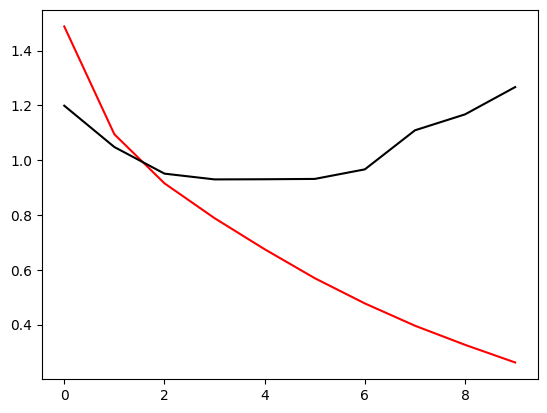

In [69]:
plt.plot(progresso.history['loss'], color='red')
plt.plot(progresso.history['val_loss'], color='black')
plt.show()

In [70]:
pred = model.predict(x_test)
print(pred[0])
print('Index:', np.argmax(pred[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
[3.4743218e-05 4.5874852e-04 6.6848489e-04 9.0601528e-01 5.8117840e-02
 2.4666421e-02 9.7320247e-03 1.0367291e-05 2.0331038e-04 9.2698167e-05]
Index: 3


In [71]:
y_classes = [np.argmax(element) for element in pred]
print('Predicted_values: ', y_classes[:10])
print('Actual_values: ', y_test[:10])

Predicted_values:  [np.int64(3), np.int64(8), np.int64(1), np.int64(0), np.int64(4), np.int64(6), np.int64(1), np.int64(6), np.int64(3), np.int64(1)]
Actual_values:  [3 8 8 0 6 6 1 6 3 1]
